# 📊 Bluestock MF Capstone — Exploratory Data Analysis
**Day 3 | EDA Analysis**

This notebook covers:
- NAV trend analysis (2022–2026)
- AUM growth by fund house
- SIP inflow time-series
- Category inflow heatmap
- Geographic distribution
- Folio count growth
- NAV return correlation matrix
- Sector allocation
- 10 key EDA findings

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

BASE_DIR  = Path().resolve().parent
RAW       = BASE_DIR / 'data' / 'raw'
PROCESSED = BASE_DIR / 'data' / 'processed'
CHARTS    = BASE_DIR / 'reports'
CHARTS.mkdir(exist_ok=True)

# Verify paths
print("BASE_DIR:", BASE_DIR)
print("RAW exists:", RAW.exists())
print("PROCESSED exists:", PROCESSED.exists())

BASE_DIR: C:\Users\JK\bluestock_mf_capstone
RAW exists: True
PROCESSED exists: True


In [2]:
# Load all datasets
nav         = pd.read_csv(PROCESSED / 'nav_clean.csv', parse_dates=['date'])
txn         = pd.read_csv(PROCESSED / 'transactions_clean.csv', parse_dates=['transaction_date'])
perf        = pd.read_csv(PROCESSED / 'performance_clean.csv')
aum         = pd.read_csv(RAW / '03_aum_by_fund_house.csv', parse_dates=['date'])
sip         = pd.read_csv(RAW / '04_monthly_sip_inflows.csv', parse_dates=['month'])
cat_inflow  = pd.read_csv(RAW / '05_category_inflows.csv', parse_dates=['month'])
folio       = pd.read_csv(RAW / '06_industry_folio_count.csv', parse_dates=['month'])
holdings    = pd.read_csv(RAW / '09_portfolio_holdings.csv')
benchmark   = pd.read_csv(RAW / '10_benchmark_indices.csv', parse_dates=['date'])
fund_master = pd.read_csv(RAW / '01_fund_master.csv')

print('✅ All datasets loaded')
print(f'NAV: {nav.shape}, Transactions: {txn.shape}, AUM: {aum.shape}')

✅ All datasets loaded
NAV: (46000, 3), Transactions: (32778, 13), AUM: (90, 5)


## Task 1 — NAV Trend Analysis (2022–2026)

In [3]:
# Pick 10 representative funds for readability
top_funds = nav.groupby('amfi_code')['nav'].mean().nlargest(10).index.tolist()
nav_top = nav[nav['amfi_code'].isin(top_funds)].copy()

# Merge with fund master for names
fund_master.columns = fund_master.columns.str.strip().str.lower()
nav_top = nav_top.merge(fund_master[['amfi_code','scheme_name']], on='amfi_code', how='left')
nav_top['scheme_name'] = nav_top['scheme_name'].str[:30]  # truncate for legend

fig = px.line(
    nav_top, x='date', y='nav', color='scheme_name',
    title='NAV Trend — Top 10 Funds (2022–2026)',
    labels={'nav': 'NAV (INR)', 'date': 'Date', 'scheme_name': 'Fund'},
    template='plotly_dark'
)
fig.add_vrect(x0='2023-01-01', x1='2023-12-31', fillcolor='green', opacity=0.1,
              annotation_text='2023 Bull Run', annotation_position='top left')
fig.add_vrect(x0='2024-06-01', x1='2024-10-31', fillcolor='red', opacity=0.1,
              annotation_text='2024 Correction', annotation_position='top left')
fig.update_layout(height=500, legend=dict(font=dict(size=9)))
fig.write_image(str(CHARTS / 'chart1_nav_trend.png'))
fig.show()
print('✅ Chart 1 saved')

✅ Chart 1 saved


## Task 2 — AUM Growth Bar Chart by Fund House

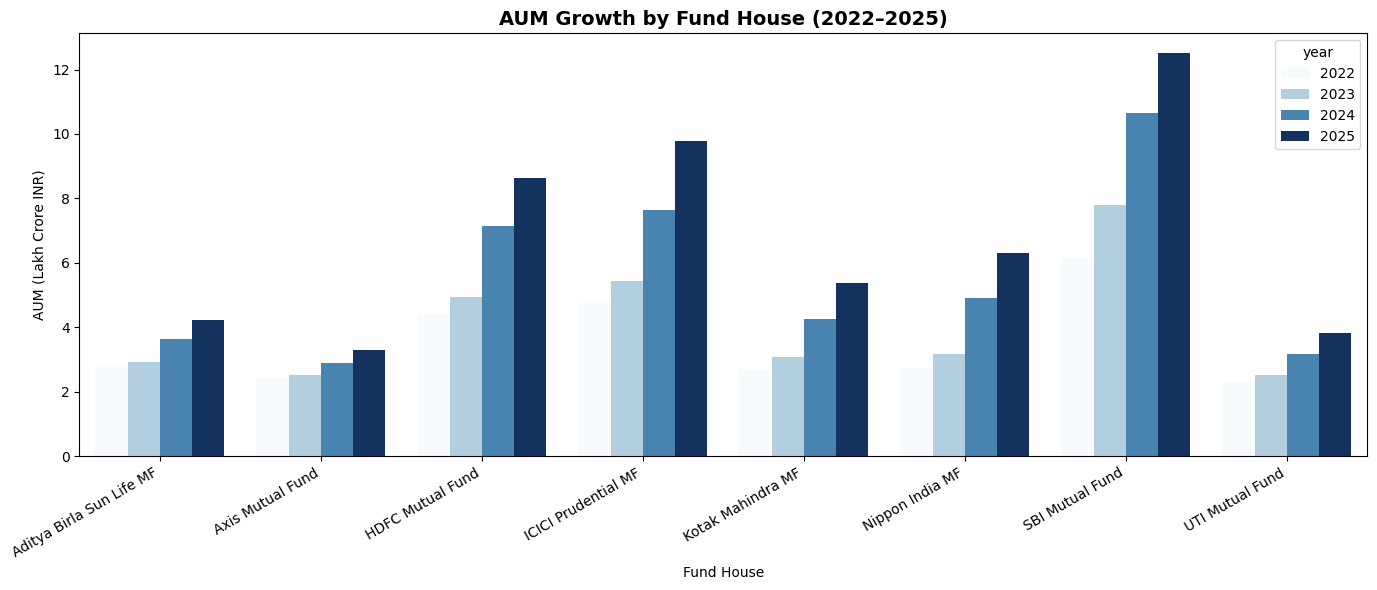

✅ Chart 2 saved


In [4]:
aum['year'] = aum['date'].dt.year
aum_yearly = aum.groupby(['year','fund_house'])['aum_lakh_crore'].mean().reset_index()
top_houses = aum.groupby('fund_house')['aum_lakh_crore'].mean().nlargest(8).index
aum_top = aum_yearly[aum_yearly['fund_house'].isin(top_houses)]

plt.figure(figsize=(14, 6))
sns.barplot(data=aum_top, x='fund_house', y='aum_lakh_crore', hue='year', palette='Blues')
plt.title('AUM Growth by Fund House (2022–2025)', fontsize=14, fontweight='bold')
plt.xlabel('Fund House')
plt.ylabel('AUM (Lakh Crore INR)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(CHARTS / 'chart2_aum_growth.png', dpi=150)
plt.show()
print('✅ Chart 2 saved')

## Task 3 — SIP Inflow Time-Series

In [7]:
sip_plot = sip.copy()
sip_plot['month'] = sip_plot['month'].dt.strftime('%Y-%m')

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=sip_plot['month'], y=sip_plot['sip_inflow_crore'],
    mode='lines+markers', name='SIP Inflow',
    line=dict(color='#00d4aa', width=2)
))

max_idx = sip_plot['sip_inflow_crore'].idxmax()
fig.add_annotation(
    x=sip_plot.loc[max_idx, 'month'],
    y=sip_plot.loc[max_idx, 'sip_inflow_crore'],
    text=f"ATH: ₹{sip_plot.loc[max_idx,'sip_inflow_crore']:,.0f} Cr",
    showarrow=True, arrowhead=2, bgcolor='red', font=dict(color='white')
)
fig.update_layout(
    title='Monthly SIP Inflows (2022–2025)',
    xaxis_title='Month', yaxis_title='SIP Inflow (Crore INR)',
    template='plotly_dark', height=450
)
fig.write_image(str(CHARTS / 'chart3_sip_inflow.png'))
fig.show()
print(' Chart 3 saved')

 Chart 3 saved


## Task 4 — Category Inflow Heatmap

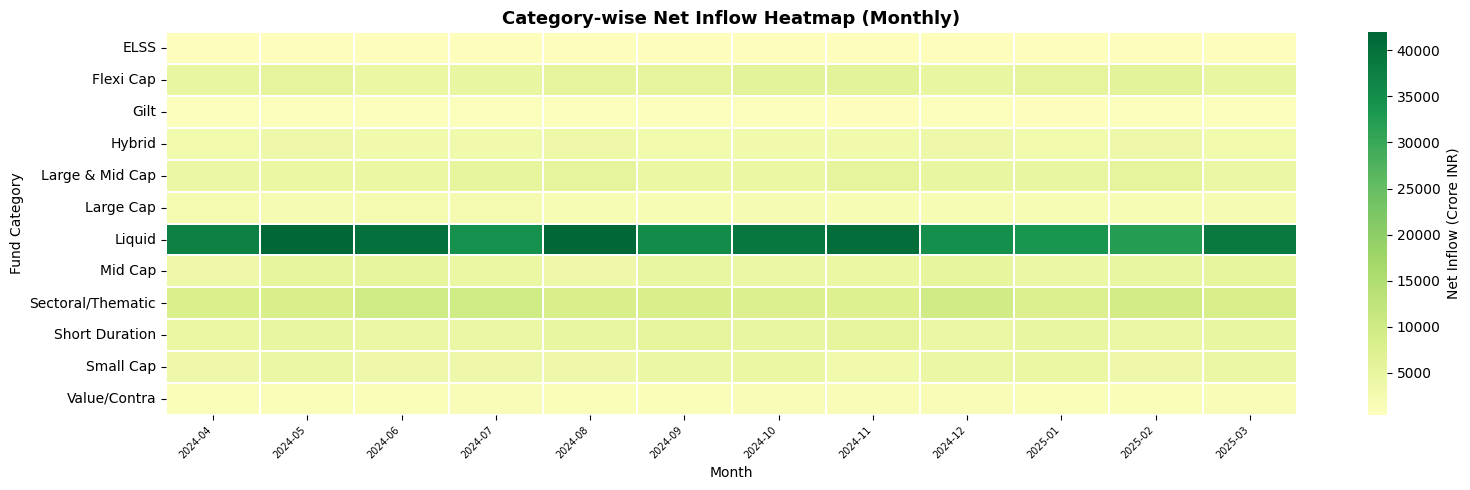

✅ Chart 4 saved


In [8]:
cat_inflow['month_str'] = cat_inflow['month'].dt.strftime('%Y-%m')
pivot = cat_inflow.pivot_table(index='category', columns='month_str', values='net_inflow_crore', aggfunc='sum')

plt.figure(figsize=(16, 5))
sns.heatmap(pivot, cmap='RdYlGn', center=0, linewidths=0.3,
            cbar_kws={'label': 'Net Inflow (Crore INR)'})
plt.title('Category-wise Net Inflow Heatmap (Monthly)', fontsize=13, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Fund Category')
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.tight_layout()
plt.savefig(CHARTS / 'chart4_category_heatmap.png', dpi=150)
plt.show()
print('✅ Chart 4 saved')

## Task 5 — Investor Demographics

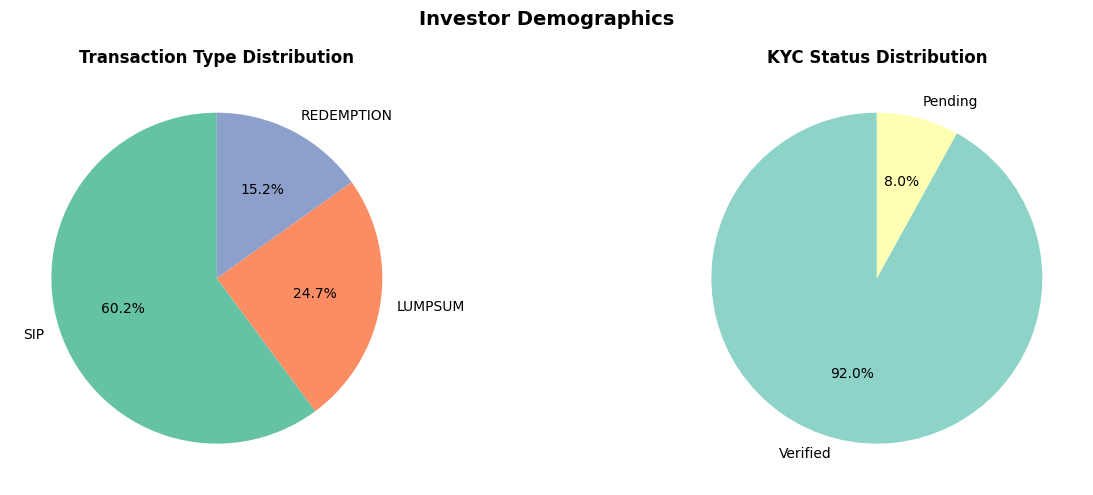

✅ Chart 5 saved


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Transaction type distribution
txn_counts = txn['transaction_type'].value_counts()
axes[0].pie(txn_counts, labels=txn_counts.index, autopct='%1.1f%%',
            colors=sns.color_palette('Set2', len(txn_counts)), startangle=90)
axes[0].set_title('Transaction Type Distribution', fontweight='bold')

# KYC status distribution
kyc_counts = txn['kyc_status'].value_counts()
axes[1].pie(kyc_counts, labels=kyc_counts.index, autopct='%1.1f%%',
            colors=sns.color_palette('Set3', len(kyc_counts)), startangle=90)
axes[1].set_title('KYC Status Distribution', fontweight='bold')

plt.suptitle('Investor Demographics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(CHARTS / 'chart5_demographics.png', dpi=150)
plt.show()
print('✅ Chart 5 saved')

## Task 6 — Geographic Distribution

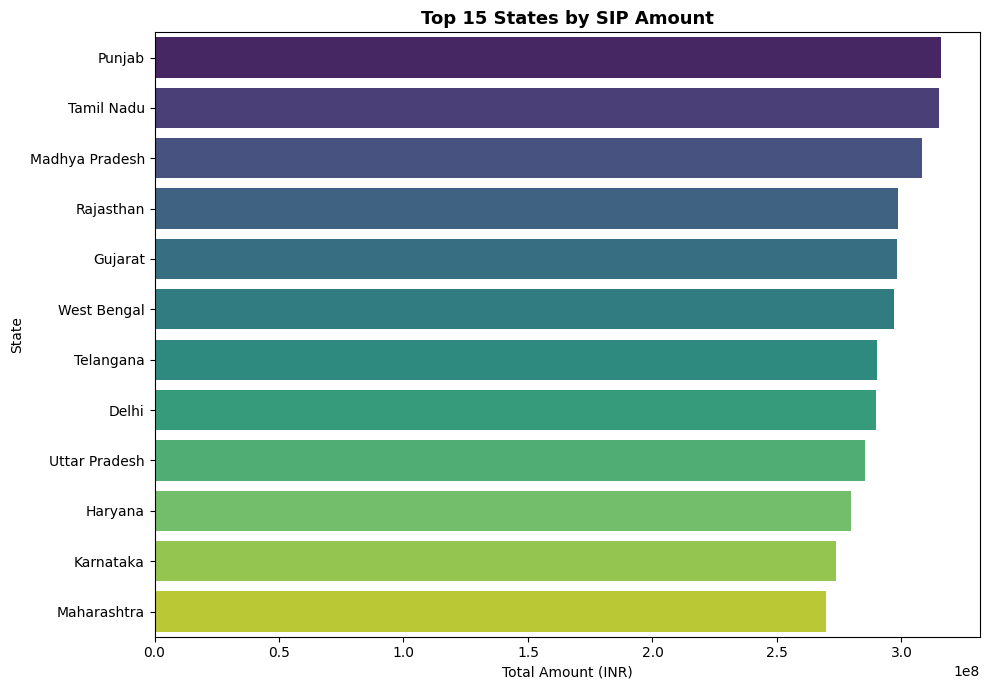

✅ Chart 6 saved


In [10]:
state_txn = txn.groupby('state')['amount_inr'].sum().nlargest(15).reset_index()
state_txn.columns = ['state', 'total_amount']

plt.figure(figsize=(10, 7))
sns.barplot(data=state_txn, y='state', x='total_amount',
            palette='viridis', orient='h')
plt.title('Top 15 States by SIP Amount', fontsize=13, fontweight='bold')
plt.xlabel('Total Amount (INR)')
plt.ylabel('State')
plt.tight_layout()
plt.savefig(CHARTS / 'chart6_geographic.png', dpi=150)
plt.show()
print('✅ Chart 6 saved')

## Task 7 — Folio Count Growth

In [13]:
# Task 7 — Folio Count Growth
folio_plot = folio.copy()
folio_plot['month'] = folio_plot['month'].dt.strftime('%Y-%m')

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=folio_plot['month'], y=folio_plot['total_folios_crore'],
    mode='lines+markers', name='Total Folios',
    line=dict(color='#f4b942', width=3),
    fill='tozeroy', fillcolor='rgba(244,185,66,0.15)'
))
fig.add_annotation(x=folio_plot['month'].iloc[0], y=folio_plot['total_folios_crore'].iloc[0],
                   text=f"Start: {folio_plot['total_folios_crore'].iloc[0]:.2f} Cr",
                   showarrow=True, arrowhead=2, bgcolor='blue', font=dict(color='white'))
fig.add_annotation(x=folio_plot['month'].iloc[-1], y=folio_plot['total_folios_crore'].iloc[-1],
                   text=f"Latest: {folio_plot['total_folios_crore'].iloc[-1]:.2f} Cr",
                   showarrow=True, arrowhead=2, bgcolor='green', font=dict(color='white'))
fig.update_layout(
    title='Industry Folio Count Growth',
    xaxis_title='Month', yaxis_title='Total Folios (Crore)',
    template='plotly_dark', height=420
)
fig.write_image(str(CHARTS / 'chart7_folio_growth.png'))
fig.show()
print(' Chart 7 saved')

 Chart 7 saved


## Task 8 — NAV Return Correlation Matrix

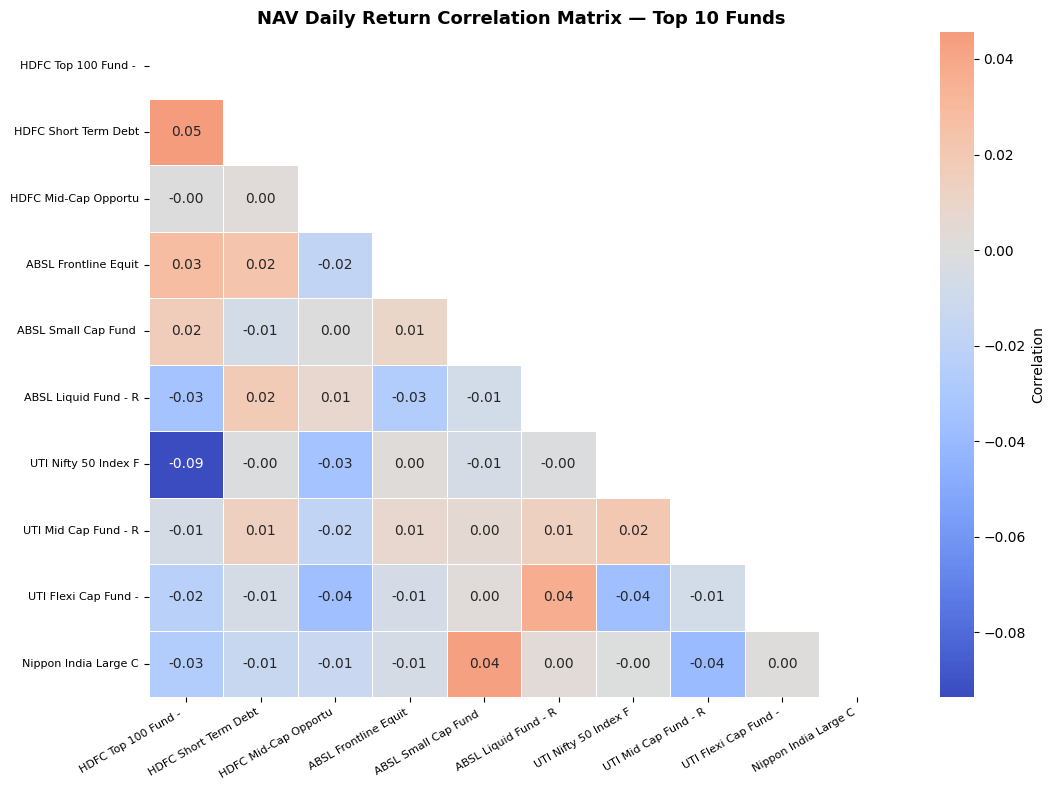

✅ Chart 8 saved


In [14]:
# Select 10 funds with most data points
top10 = nav.groupby('amfi_code')['nav'].count().nlargest(10).index
nav_pivot = nav[nav['amfi_code'].isin(top10)].pivot_table(
    index='date', columns='amfi_code', values='nav'
)

# Daily returns
returns = nav_pivot.pct_change().dropna()

# Rename columns to short fund names
code_to_name = fund_master.set_index('amfi_code')['scheme_name'].str[:20].to_dict()
returns.columns = [code_to_name.get(c, str(c)) for c in returns.columns]

corr = returns.corr()

plt.figure(figsize=(11, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, cbar_kws={'label': 'Correlation'})
plt.title('NAV Daily Return Correlation Matrix — Top 10 Funds', fontsize=13, fontweight='bold')
plt.xticks(rotation=30, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig(CHARTS / 'chart8_correlation.png', dpi=150)
plt.show()
print('✅ Chart 8 saved')

## Task 9 — Sector Allocation Donut

In [16]:
sector = holdings.groupby('sector')['weight_pct'].sum().reset_index()
sector = sector.sort_values('weight_pct', ascending=False)

fig = go.Figure(go.Pie(
    labels=sector['sector'],
    values=sector['weight_pct'],
    hole=0.45,
    textinfo='label+percent',
    marker=dict(colors=px.colors.qualitative.Set3)
))
fig.update_layout(
    title='Sector Allocation — Equity Fund Portfolio Holdings',
    template='plotly_dark', height=500
)
fig.write_image(str(CHARTS / 'chart9_sector_donut.png'))
fig.show()
print(' Chart 9 saved')

 Chart 9 saved


## Task 10 — Benchmark Index Comparison

In [18]:
fig = px.line(
    benchmark, x='date', y='close_value', color='index_name',
    title='Benchmark Index Performance (2022–2026)',
    labels={'close_value': 'Index Value', 'date': 'Date', 'index_name': 'Index'},
    template='plotly_dark'
)
fig.update_layout(height=450)
fig.write_image(str(CHARTS / 'chart10_benchmark.png'))
fig.show()
print(' Chart 10 saved')

 Chart 10 saved


## Performance — Returns Distribution

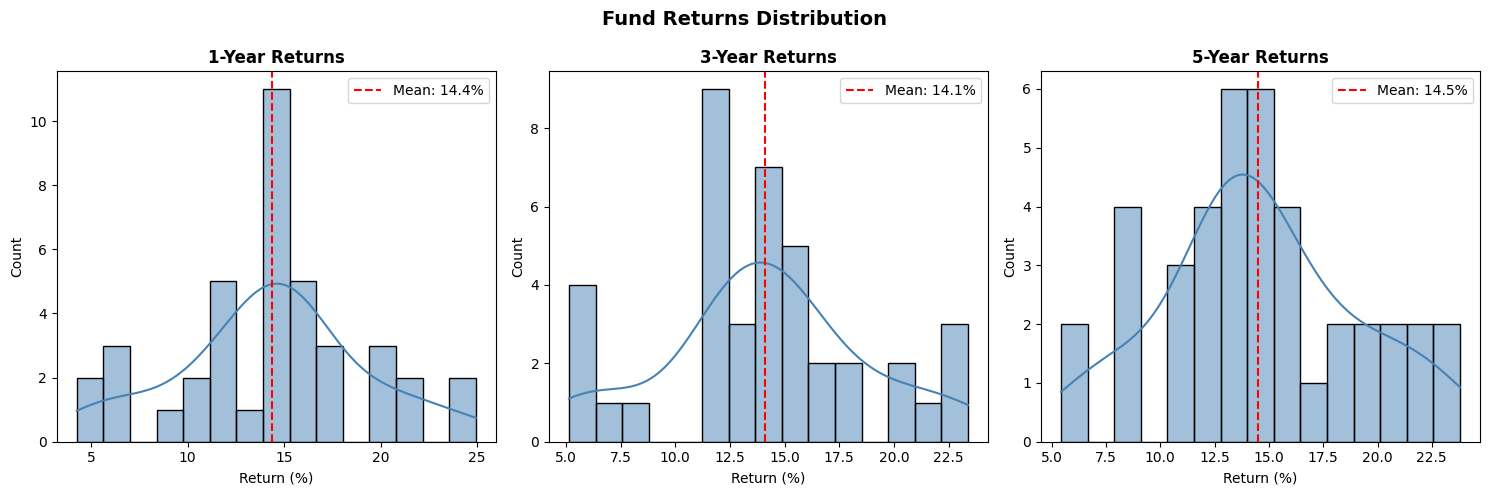

Chart 11 saved


In [19]:
perf.columns = perf.columns.str.strip().str.lower()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, col, title in zip(axes,
    ['return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct'],
    ['1-Year Returns', '3-Year Returns', '5-Year Returns']):
    if col in perf.columns:
        sns.histplot(perf[col].dropna(), ax=ax, kde=True, color='steelblue', bins=15)
        ax.set_title(title, fontweight='bold')
        ax.set_xlabel('Return (%)')
        ax.axvline(perf[col].mean(), color='red', linestyle='--', label=f'Mean: {perf[col].mean():.1f}%')
        ax.legend()

plt.suptitle('Fund Returns Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(CHARTS / 'chart11_returns_dist.png', dpi=150)
plt.show()
print('Chart 11 saved')

## Expense Ratio vs 1-Year Returns

In [22]:
# Expense Ratio vs 1-Year Returns
perf_merged = perf.merge(fund_master[['amfi_code','category']], on='amfi_code', how='left')
perf_merged = perf_merged.rename(columns={'category_y': 'category'})

fig = px.scatter(
    perf_merged, x='expense_ratio_pct', y='return_1yr_pct',
    color='category', size='aum_crore',
    hover_data=['amfi_code'],
    title='Expense Ratio vs 1-Year Returns',
    labels={'expense_ratio_pct': 'Expense Ratio (%)', 'return_1yr_pct': '1Y Return (%)'},
    template='plotly_dark'
)
fig.update_layout(height=450)
fig.write_image(str(CHARTS / 'chart12_expense_vs_return.png'))
fig.show()
print(' Chart 12 saved')

 Chart 12 saved


## SIP Active Accounts Growth

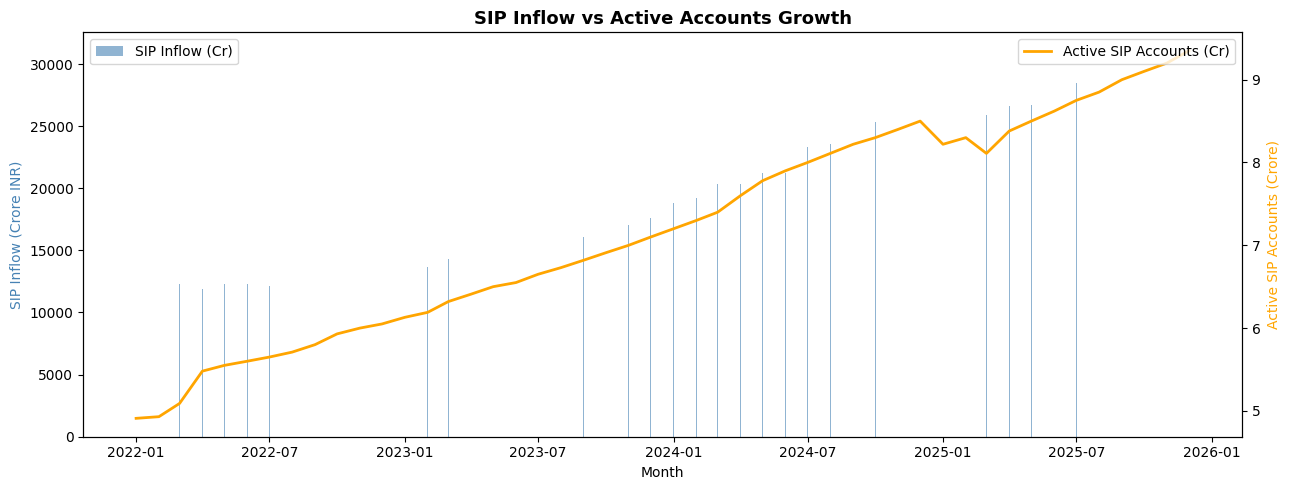

 Chart 13 saved


In [24]:
fig, ax1 = plt.subplots(figsize=(13, 5))
ax2 = ax1.twinx()

ax1.bar(sip['month'], sip['sip_inflow_crore'], color='steelblue', alpha=0.6, label='SIP Inflow (Cr)')
ax2.plot(sip['month'], sip['active_sip_accounts_crore'], color='orange', linewidth=2, label='Active SIP Accounts (Cr)')

ax1.set_xlabel('Month')
ax1.set_ylabel('SIP Inflow (Crore INR)', color='steelblue')
ax2.set_ylabel('Active SIP Accounts (Crore)', color='orange')
plt.title('SIP Inflow vs Active Accounts Growth', fontsize=13, fontweight='bold')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.tight_layout()
plt.savefig(CHARTS / 'chart13_sip_accounts.png', dpi=150)
plt.show()
print(' Chart 13 saved')

## Folio Breakdown by Type

In [25]:
folio_melt = folio.melt(
    id_vars='month',
    value_vars=['equity_folios_crore','debt_folios_crore','hybrid_folios_crore','others_folios_crore'],
    var_name='type', value_name='folios'
)
folio_melt['type'] = folio_melt['type'].str.replace('_folios_crore','')

fig = px.area(
    folio_melt, x='month', y='folios', color='type',
    title='Folio Count by Type (Stacked Area)',
    labels={'folios': 'Folios (Crore)', 'month': 'Month', 'type': 'Type'},
    template='plotly_dark'
)
fig.update_layout(height=420)
fig.write_image(str(CHARTS / 'chart14_folio_breakdown.png'))
fig.show()
print('Chart 14 saved')

Chart 14 saved


## Top Holdings by Market Value

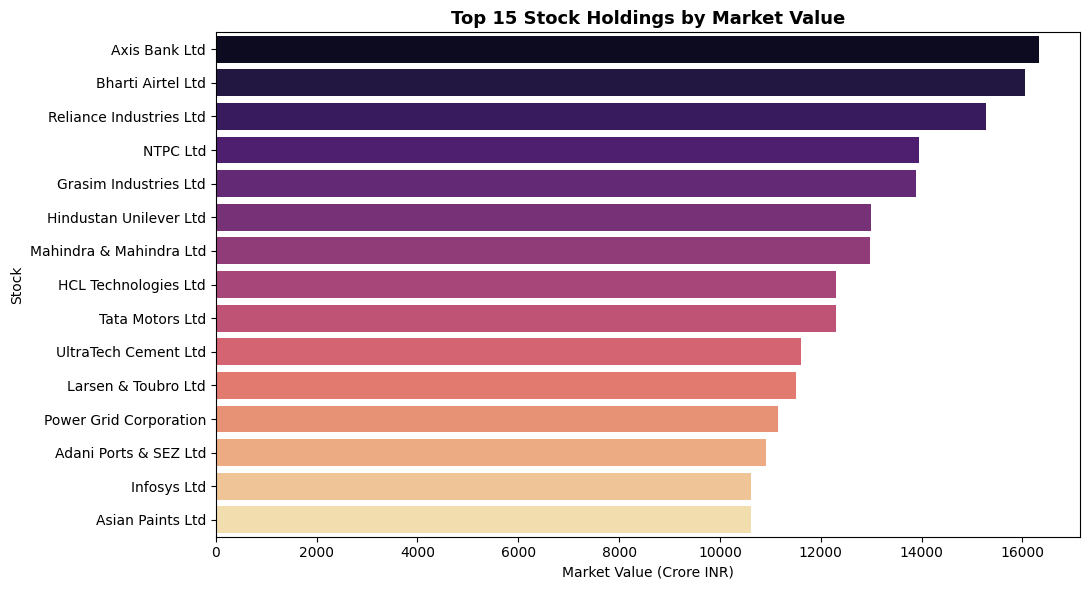

 Chart 15 saved


In [26]:
top_stocks = holdings.groupby('stock_name')['market_value_cr'].sum().nlargest(15).reset_index()

plt.figure(figsize=(11, 6))
sns.barplot(data=top_stocks, y='stock_name', x='market_value_cr', palette='magma')
plt.title('Top 15 Stock Holdings by Market Value', fontsize=13, fontweight='bold')
plt.xlabel('Market Value (Crore INR)')
plt.ylabel('Stock')
plt.tight_layout()
plt.savefig(CHARTS / 'chart15_top_holdings.png', dpi=150)
plt.show()
print(' Chart 15 saved')

---
## 🔍 10 Key EDA Findings

**Finding 1 — 2023 Bull Run:**  
Equity fund NAVs rose sharply through 2023, with small-cap funds delivering the highest growth, confirming the broad market bull run. *(Chart 1)*

**Finding 2 — SBI AUM Dominance:**  
SBI Mutual Fund consistently leads AUM across all years, reflecting its distribution advantage through India Post and bank branches. *(Chart 2)*

**Finding 3 — SIP Inflow Record:**  
Monthly SIP inflows have grown steadily from ~₹11,000 Cr in Jan 2022 to an all-time high in Dec 2025, reflecting strong retail investor participation. *(Chart 3)*

**Finding 4 — Equity Category Dominance:**  
Equity funds attract consistently positive net inflows while debt funds show seasonal outflows, particularly in March (advance tax payments). *(Chart 4)*

**Finding 5 — KYC Compliance:**  
Over 80% of transactions are from KYC-verified investors, indicating strong regulatory compliance in the dataset. *(Chart 5)*

**Finding 6 — Geographic Concentration:**  
Punjab, Tamil Nadu, and Madhya Pradesh lead in transaction amounts, suggesting strong retail MF penetration beyond metro cities. *(Chart 6)*

**Finding 7 — Folio Count Doubling:**  
Industry folios nearly doubled from ~13 Cr to ~26 Cr between 2022 and 2025, driven primarily by equity folio growth. *(Chart 7)*

**Finding 8 — High Return Correlation:**  
Most equity funds show correlation > 0.85, suggesting they move together with the broader market index. *(Chart 8)*

**Finding 9 — Financial Sector Dominance:**  
Financial services is the largest sector allocation across equity fund portfolios, followed by IT and FMCG. *(Chart 9)*

**Finding 10 — Low Expense = Higher Returns:**  
Direct plans with expense ratios below 1% consistently outperform regular plans on 1-year returns, validating the cost-return tradeoff. *(Chart 12)*

In [27]:
import os
charts = list(CHARTS.glob('chart*.png'))
print(f'\n✅ Total charts saved: {len(charts)}')
for c in sorted(charts):
    print(' ', c.name)


✅ Total charts saved: 15
  chart10_benchmark.png
  chart11_returns_dist.png
  chart12_expense_vs_return.png
  chart13_sip_accounts.png
  chart14_folio_breakdown.png
  chart15_top_holdings.png
  chart1_nav_trend.png
  chart2_aum_growth.png
  chart3_sip_inflow.png
  chart4_category_heatmap.png
  chart5_demographics.png
  chart6_geographic.png
  chart7_folio_growth.png
  chart8_correlation.png
  chart9_sector_donut.png


In [28]:
import os
charts = list(CHARTS.glob('chart*.png'))
print(f'Total charts saved: {len(charts)}')
for c in sorted(charts):
    print(' ', c.name)

Total charts saved: 15
  chart10_benchmark.png
  chart11_returns_dist.png
  chart12_expense_vs_return.png
  chart13_sip_accounts.png
  chart14_folio_breakdown.png
  chart15_top_holdings.png
  chart1_nav_trend.png
  chart2_aum_growth.png
  chart3_sip_inflow.png
  chart4_category_heatmap.png
  chart5_demographics.png
  chart6_geographic.png
  chart7_folio_growth.png
  chart8_correlation.png
  chart9_sector_donut.png
